In [ ]:
import numpy as np
from scipy.stats import ttest_ind, t
import matplotlib.pyplot as plt

___

## Задание 1: t-test для независимых выборок (критерий Уэлча)
### Реализуйте тест Уэлча на python.
Для двух независимых выборок напишите функцию, которая возвращает значение t-статистики. Функция должна принимать на вход два массива, а возвращать значение t-статистики. В описании функции укажите статистическую гипотезу, для которой применяется критерий Уэлча.

P.s. Использовать ttest_ind запрещено

___

In [ ]:
def t_statistic(x, y) -> float:
    """
    Вычисляет t-статистику критерия Уэлча для двух независимых выборок.

    Статистическая гипотеза равенства средних:
      H_0: μ_x − μ_y = 0
      H_1: μ_x − μ_y ≠ 0  (двусторонняя, в случае односторонней > или <).
    Предположения: независимость выборок; нормальность не требуется строго при больших n;
    равенство дисперсий не предполагается.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = x.size, y.size
    if n1 < 2 or n2 < 2:
        raise ValueError("Каждая выборка должна содержать минимум 2 конечных наблюдения.")

    x_mean, y_mean = x.mean(), y.mean()
    s1, s2 = x.var(ddof=1), y.var(ddof=1)

    d = np.sqrt(s1 / n1 + s2 / n2)
    if d == 0.0:
        diff = (x_mean - y_mean)
        return 0.0 if diff == 0.0 else np.copysign(np.inf, diff)

    return (x_mean - y_mean) / d

## Задание 2: Распределение t-статистики
### Используя метод Монте-Карло, постройте гистограмму распределения t-статистики для двух случаев:
1. Выборки взяты из одного равномерного распределения с параметрами a = 400, b = 2000.
2. Выборки взяты из разных нормальных распределений. Параметры распределений: mu_1 = 1210, sigma_1 = 500, mu_2 = 1200, sigma_2 = 350.

Для построения гистограмы будет достаточно выборок объёмом в 10000 наблюдений каждая.

Используйте функцию из задания 1

In [ ]:
from scipy.stats import norm, uniform

In [ ]:
 def summarize(arr):
      return {
          "mean": float(np.mean(arr)),
          "std": float(np.std(arr, ddof=1)),
          "q25": float(np.quantile(arr, 0.25)),
          "q50": float(np.quantile(arr, 0.50)),
          "q75": float(np.quantile(arr, 0.75)),
      }

Uniform vs Uniform: {'mean': 0.03649943923366695, 'std': 0.9905156652369483, 'q25': -0.6667544946920306, 'q50': 0.06710458469342695, 'q75': 0.7080100921269558}


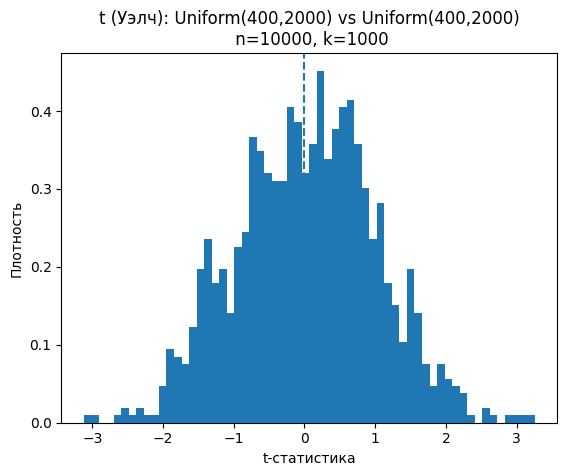

Normal vs Normal: {'mean': 1.6331779972145892, 'std': 1.006489029249006, 'q25': 0.94798019654796, 'q50': 1.6184073525897174, 'q75': 2.3064530390929194}


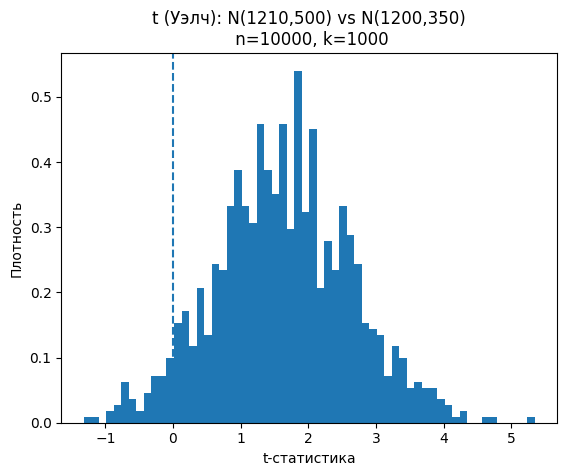

In [ ]:
rng = np.random.default_rng(42)

n = 10000 # размер каждой выборки
k = 1000 #итераций метода Монте-Карло

t_uniform = np.empty(k, dtype=float)
for i in range(k):
    x = rng.uniform(400, 2000, size=n)
    y = rng.uniform(400, 2000, size=n)
    t_uniform[i] = t_statistic(x, y)

t_normals = np.empty(k, dtype=float)
for i in range(k):
    x = rng.normal(1210.0, 500.0, size=n)
    y = rng.normal(1200.0, 350.0, size=n)
    t_normals[i] = t_statistic(x, y)

print("Uniform vs Uniform:", summarize(t_uniform))

plt.figure()
plt.hist(t_uniform, bins=60, density=True) #нормируем гистограмму, чтобы площадь под графиком была равна 1
plt.axvline(0, linestyle="--")
plt.title("t (Уэлч): Uniform(400,2000) vs Uniform(400,2000)\n n=10000, k=%d" % k)
plt.xlabel("t-статистика")
plt.ylabel("Плотность")
plt.show()

print("Normal vs Normal:", summarize(t_normals))

plt.figure()
plt.hist(t_normals, bins=60, density=True) #нормируем гистограмму, чтобы площадь под графиком была равна 1
plt.axvline(0, linestyle="--")
plt.title("t (Уэлч): N(1210,500) vs N(1200,350)\n n=10000, k=%d" % k)
plt.xlabel("t-статистика")
plt.ylabel("Плотность")
plt.show()

___

## Задание 3: Связь t-распределения стьюдента с нормальным распределением
Распределение Стьюдента является однопараметрическим и зависит от n, числа случайных величин (т.е. от объёма выборки). Для случая (1) из задания 2 постройте несколько разных распределений t-статистики для выборок объёма 50, 1000 и 10000 элементов. Сравните полученные распределения с нормальным распределением, какими параметрами оно должно обладать?

Для расчета t-статистики используйте функцию из задания 1

Uniform vs Uniform - 1: {'mean': 0.02115024417007694, 'std': 1.0228565869972341, 'q25': -0.6502165481811877, 'q50': 0.0013022016037192137, 'q75': 0.7041508803304534}


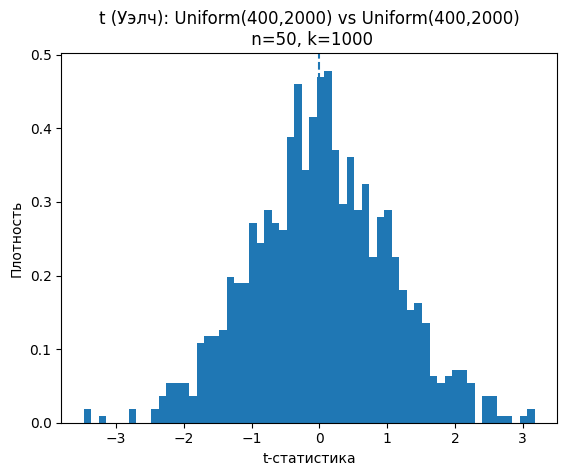

Uniform vs Uniform - 2: {'mean': -0.06655758963292156, 'std': 0.9779630016510187, 'q25': -0.7756227984215733, 'q50': -0.045772668733351826, 'q75': 0.6187783712179322}


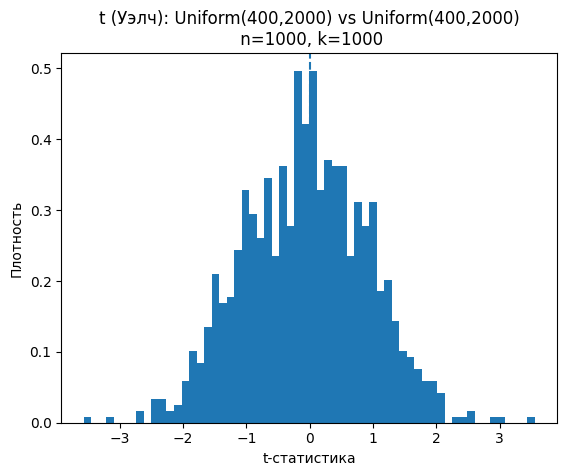

Uniform vs Uniform - 3: {'mean': 0.02161331235477259, 'std': 0.9936207024412244, 'q25': -0.6667544946920306, 'q50': 0.047762328204760326, 'q75': 0.6845049598808538}


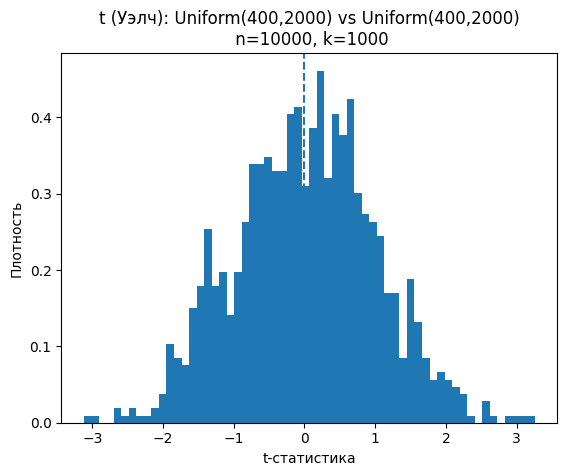

In [ ]:
rng = np.random.default_rng(42)
k = 1000 #итераций метода Монте-Карло

t_uniform1 = np.empty(k, dtype=float)
for i in range(k):
    x = rng.uniform(400, 2000, size=50)
    y = rng.uniform(400, 2000, size=50)
    t_uniform1[i] = t_statistic(x, y)

print("Uniform vs Uniform - 1:", summarize(t_uniform1))

plt.figure()
plt.hist(t_uniform1, bins=60, density=True) #нормируем гистограмму, чтобы площадь под графиком была равна 1
plt.axvline(0, linestyle="--")
plt.title("t (Уэлч): Uniform(400,2000) vs Uniform(400,2000)\n n=50, k=%d" % k)
plt.xlabel("t-статистика")
plt.ylabel("Плотность")
plt.show()

t_uniform2 = np.empty(k, dtype=float)
for i in range(k):
    x = rng.uniform(400, 2000, size=1000)
    y = rng.uniform(400, 2000, size=1000)
    t_uniform2[i] = t_statistic(x, y)

print("Uniform vs Uniform - 2:", summarize(t_uniform2))

plt.figure()
plt.hist(t_uniform2, bins=60, density=True) #нормируем гистограмму, чтобы площадь под графиком была равна 1
plt.axvline(0, linestyle="--")
plt.title("t (Уэлч): Uniform(400,2000) vs Uniform(400,2000)\n n=1000, k=%d" % k)
plt.xlabel("t-статистика")
plt.ylabel("Плотность")
plt.show()

t_uniform3 = np.empty(k, dtype=float)
for i in range(k):
    x = rng.uniform(400, 2000, size=10000)
    y = rng.uniform(400, 2000, size=10000)
    t_uniform3[i] = t_statistic(x, y)

print("Uniform vs Uniform - 3:", summarize(t_uniform3))

plt.figure()
plt.hist(t_uniform3, bins=60, density=True) #нормируем гистограмму, чтобы площадь под графиком была равна 1
plt.axvline(0, linestyle="--")
plt.title("t (Уэлч): Uniform(400,2000) vs Uniform(400,2000)\n n=10000, k=%d" % k)
plt.xlabel("t-статистика")
plt.ylabel("Плотность")
plt.show()

При верной $H_0$ и больших $n$(объём выборки) t-распределение сходится к нормальному:
$\mathcal{N}(0,1)$ — т.е. среднее $0$ и стандартное отклонение $1$.

Для $n=50$ хвосты чуть тяжелее; Для $n=1000$ и $n=10000$ — почти неотличимо от $\mathcal{N}(0,1)$.

___

## Задание 4: Расчёт p-value на основе знания t-статистики
Для случая (2) из задания 2 с выборками объёмом в 10000 элементов посчитайте значение t-статистики. Вычислите значение p-value для получившегося значения t-статистики.

Добавьте в функцию реализации теста Уэлча из задания 1 расчёт p-value на основе рассчитанного значения t-статистики. Функция должна принимать на вход два массива, а возвращать значения t-статистики и p-value для двусторонней альтернативной гипотезы. Текстом напишите ответ на вопрос: как будет отличаться p-value для односторонней и двусторонней альтернативной гипотезы?

In [ ]:
def t_statistic_with_pvalue(x, y):
    """
    Вычисляет t-статистику критерия Уэлча для двух независимых выборок.

    Статистическая гипотеза равенства средних:
      H_0: μ_x − μ_y = 0
      H_1: μ_x − μ_y ≠ 0  (двусторонняя, в случае односторонней > или <).
    Предположения: независимость выборок; нормальность не требуется строго при больших n;
    равенство дисперсий не предполагается.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    n1, n2 = x.size, y.size
    if n1 < 2 or n2 < 2:
        raise ValueError("Каждая выборка должна содержать минимум 2 конечных наблюдения.")

    x_mean, y_mean = x.mean(), y.mean()
    s1, s2 = x.var(ddof=1), y.var(ddof=1)

    d = np.sqrt(s1 / n1 + s2 / n2)
    if d == 0.0:
        diff = (x_mean - y_mean)
        t_stat = 0.0 if diff == 0.0 else np.copysign(np.inf, diff)
        return t_stat, 1.0 if np.isfinite(t_stat) and t_stat == 0.0 else 0.0

    t_stat = (x_mean - y_mean) / d

    #аппроксимация степеней свободы Уэлча–Саттертуэйта
    num = (s1/n1 + s2/n2)**2
    den = (s1**2)/(n1**2*(n1-1)) + (s2**2)/(n2**2*(n2-1))
    df = num/den

    pvalue = 2 * t.sf(np.abs(t_stat), df)

    return float(t_stat), float(pvalue)

In [ ]:
rng = np.random.default_rng(42)

x = rng.normal(1210.0, 500.0, size=10000)
y = rng.normal(1200.0, 350.0, size=10000)

t_stat, pvalue = t_statistic_with_pvalue(x, y)
print("t_value = ", t_stat, "; p-value = ", pvalue)

t_value =  -0.36642185403257377 ; p-value =  0.714054653352264


___

## Задание 5: Применение t_test_ind из scipy. Метод 1000 тестов.
1. Для случаев (1) и (2) из задания 2 примените вашу функцию для вычисления результатов t-test и функцию ttest_ind из scipy. Сравните результаты.
2. Для случая (1) из задания 2 примените метод Монте-Карло с имитацией 1000 А/А-тестов и постройте распределение p-value. Опишите, какое распределение вы получили?

In [ ]:
rng = np.random.default_rng(42)

x = rng.uniform(400, 2000, size=10000)
y = rng.uniform(400, 2000, size=10000)

print("Uniform distribution")
t_stat, pvalue = t_statistic_with_pvalue(x, y)
print("t_statistic_with_pvalue results: t_value = ", t_stat, "; p-value = ", pvalue)

t_stat, pvalue = ttest_ind(x, y, equal_var=False, alternative="two-sided")
print("ttest_ind results: t_value = ", t_stat, "; p-value = ", pvalue)

x = rng.normal(1210.0, 500.0, size=10000)
y = rng.normal(1200.0, 350.0, size=10000)

print()

print("Normal distribution")
t_stat, pvalue = t_statistic_with_pvalue(x, y)
print("t_statistic_with_pvalue results: t_value = ", t_stat, "; p-value = ", pvalue)

t_stat, pvalue = ttest_ind(x, y, equal_var=False, alternative="two-sided")
print("ttest_ind results: t_value = ", t_stat, "; p-value = ", pvalue)

Uniform distribution
t_statistic_with_pvalue results: t_value =  -1.4246142947610592 ; p-value =  0.154284330378965
ttest_ind results: t_value =  -1.4246142947610592 ; p-value =  0.154284330378965

Normal distribution
t_statistic_with_pvalue results: t_value =  3.9062446465509937 ; p-value =  9.408533999583115e-05
ttest_ind results: t_value =  3.906244646550994 ; p-value =  9.408533999583088e-05


Результаты одинаковые(+- погрешность вычислений), значит, функция реализована верно.

{'mean': 0.49369868587032933, 'std': 0.2833399203503532, 'q25': 0.24296952223878288, 'q50': 0.49070546711136354, 'q75': 0.7332201651585213}


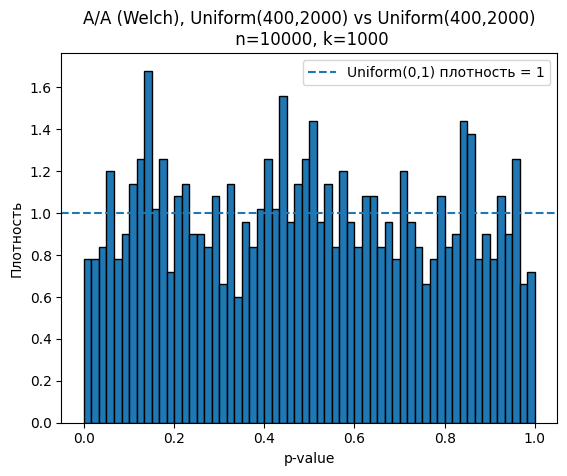

In [ ]:
rng = np.random.default_rng(42)
n = 10000
k = 1000
pvals = np.empty(k)

for i in range(k):
    x = rng.uniform(400, 2000, size=n)
    y = rng.uniform(400, 2000, size=n)
    _, pvals[i] = t_statistic_with_pvalue(x, y)


print(summarize(pvals))

plt.figure()
plt.hist(pvals, bins=60, range=(0,1), density=True, edgecolor="black")
plt.axhline(1.0, linestyle="--", label="Uniform(0,1) плотность = 1")
plt.xlabel("p-value"); plt.ylabel("Плотность")
plt.title(f"А/А (Welch), Uniform(400,2000) vs Uniform(400,2000)\n n={n}, k={k}")
plt.legend()
plt.show()

На гистограмме p-value из А/А-тестов столбцы колеблются вокруг горизонтали с плотностью ≈ 1 - это эмпирическое Uniform(0,1). Присутствует небольшой шум, возможно, из-за недостаточного числа прогонов. Этот феномен называется "калибровка p-value" (при верной $H_0$).

___

## Задание 6: Мощность t-критерия. Построение кривых мощности.
Наблюдения в двух выборках взяты из нормальных распределений с sigma = 400. Матожидание первой выборки равно 1200, а матожидание второй выборки изменяется относительно первого с некоторым шагом. Постройте кривую мощности для изменения матожидания c шагом от 0,5% до 5%.

___

[(np.float64(0.5), np.float64(0.195)), (np.float64(1.0), np.float64(0.539)), (np.float64(1.5), np.float64(0.887)), (np.float64(2.0), np.float64(0.984)), (np.float64(2.5), np.float64(1.0)), (np.float64(3.0), np.float64(1.0)), (np.float64(3.5), np.float64(1.0)), (np.float64(4.0), np.float64(1.0)), (np.float64(4.5), np.float64(1.0)), (np.float64(5.0), np.float64(1.0))]


/tmp/ipython-input-479973597.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


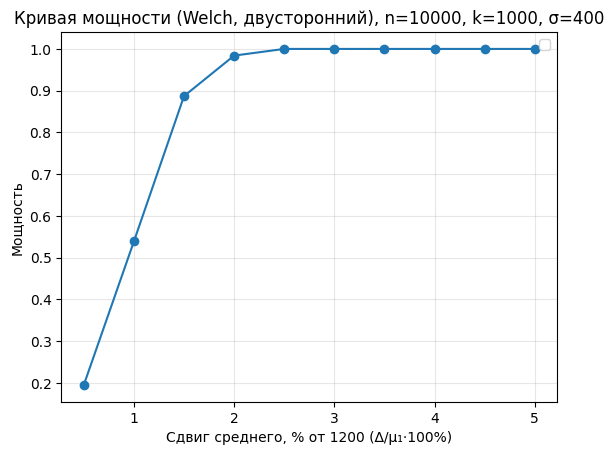

In [ ]:
mu1 = 1200
sigma = 400
n = 10000
alpha = 0.05 #стандарт
k = 1000
percents = np.linspace(0.5, 5.0, num=10)
deltas = mu1 * (percents / 100.0)

rng = np.random.default_rng(42)

powers = []
for delta in deltas:
    mu2 = mu1 + delta
    reject = 0
    for _ in range(k):
        x = rng.normal(mu1, sigma, size=n)
        y = rng.normal(mu2, sigma, size=n)
        _, p = t_statistic_with_pvalue(x, y)
        if p < alpha:
            reject += 1
    powers.append(reject / k)

powers = np.array(powers)

print(list(zip(percents, powers)))

plt.figure()
plt.plot(percents, powers, marker="o")
plt.xlabel("Сдвиг среднего, % от 1200 (∆/μ₁·100%)")
plt.ylabel("Мощность")
plt.title(f"Кривая мощности (Welch, двусторонний), n={n}, k={k}, σ=400")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Мы видим, что при малом сдвиге среднего(0.5%) мощность низкая(около 20%) - плохой результат. Между сдвигом в 1% и в 2% наблюдается резкий рост мощности теста от 55% до 98%. Затем кривая мощности выходит на плато, то есть практически неизбежное обнаружение эффекта.